# ML4HD DEMO 

Ciao a tutti! Welcome to our demo! :) We are Diego and Diana and we are really excited to share with you our final results for the gesture classifier. For simplicity purposes in this notebook we only included the necessary functions to import our preprocessed dataset, create our dataset objects and test our already trained models. In case of doubts about the models' architectures or curiosity about the programming details please refer to the "ML4HD Project" notebook, there you'll find every detail about the preprocessing, architectures and training process. 

Due to the limited time, we won't show the results of all our models. Today, we'll present the models with the best performance from every different architecture we tested. However, all the models are available to test in case of interest in a specific architecture. 

In [1]:
import h5py
import glob
import os
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.layers import BatchNormalization, MaxPool2D, Conv2D, Flatten, LSTM, Dense, TimeDistributed, Activation, GlobalAveragePooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import LearningRateScheduler

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
from numpy import load

import random

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans 
from scipy.stats import multivariate_normal
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from IPython.display import clear_output

from rdi_ds_utils import get_cnn_rnn_dataset, get_lsm_dataset, visualise_ds, filter_dataset
from rdi_model_util import LSM_Readout, load_model, test_model, create_confusion_matrix

2026-02-12 17:05:58.232154: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770915958.559592      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770915958.652480      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770915959.448486      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770915959.448627      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770915959.448631      17 computation_placer.cc:177] computation placer alr

In [2]:
#First, create the list of all file paths. This list will be used to create train/val/test splits

dataset_path = '/kaggle/input/datasets/xxdiegoalonsoxx/train-preprocessed/data_preprocessed'

all_file_paths = sorted(glob.glob(os.path.join(dataset_path, "**/*.npz"), recursive=True))

#Create Train/test splits of the file, in the paper 50/50 is used
train_paths, test_val_paths = train_test_split(all_file_paths, test_size = 0.5, random_state = 69, shuffle = True)
val_paths, test_paths = train_test_split(test_val_paths, test_size = 0.5, random_state = 69, shuffle = True)

print(f"Train Paths: {len(train_paths)}", f"Val Paths: {len(val_paths)}", f"Test Paths: {len(test_paths)}")

#Peek at the first few to ensure they look right
for path in all_file_paths[:3]:
    print(path)

Train Paths: 2750 Val Paths: 1375 Test Paths: 1375
/kaggle/input/datasets/xxdiegoalonsoxx/train-preprocessed/data_preprocessed/0_0_0.npz
/kaggle/input/datasets/xxdiegoalonsoxx/train-preprocessed/data_preprocessed/0_0_1.npz
/kaggle/input/datasets/xxdiegoalonsoxx/train-preprocessed/data_preprocessed/0_0_10.npz


In [3]:
#Function to filter the paths according to the session, used for personalized gestures to test with 50% of the dataset
sessions_data, test_paths_cv = filter_dataset(all_file_paths)

Number of files in test_paths:  2750
Session 0 has 550 files
Session 1 has 550 files
Session 4 has 550 files
Session 7 has 550 files
Session 13 has 550 files


In [4]:
#Second, create tensorflow dataset objects

cnn_rnn_train_ds = get_cnn_rnn_dataset(train_paths, batch_size = 8, target_frames = 40, norm_type = 'minmax', 
                               trunc_mode = 'first', clip_range = False, clip_amount = 20, shuffle = True)
cnn_rnn_val_ds = get_cnn_rnn_dataset(val_paths, batch_size = 8, target_frames = 40, trunc_mode = 'first',
                             norm_type = 'minmax', clip_range = False, shuffle = False)
cnn_rnn_test_ds = get_cnn_rnn_dataset(test_paths, batch_size = 8, target_frames = 40, trunc_mode = 'first',
                              norm_type = 'minmax', clip_range = False, shuffle = False)

lsm_train_ds = get_lsm_dataset(train_paths, batch_size = 8, apply_temporal = True, target_frames = 40,
                   trunc_mode = 'middle', threshold = 0, clip_range = False, shuffle = True)

lsm_val_ds = get_lsm_dataset(val_paths, batch_size = 8, apply_temporal = True, target_frames = 40,
                   trunc_mode = 'middle', threshold = 0, clip_range = False, shuffle = False)

lsm_test_ds = get_lsm_dataset(test_paths, batch_size = 8, apply_temporal = True, target_frames = 40,
                   trunc_mode = 'middle', threshold = 0, clip_range = False, shuffle = False)

#Testing dataset for personalized models with 50% of the sequences coming from different users
cnn_rnn_test_ds_cv = get_cnn_rnn_dataset(test_paths_cv, batch_size = 8, target_frames = 40, trunc_mode = 'first',
                              norm_type = 'minmax', clip_range = False, shuffle = False)

Batch Image Shape: (8, 40, 32, 32, 4)


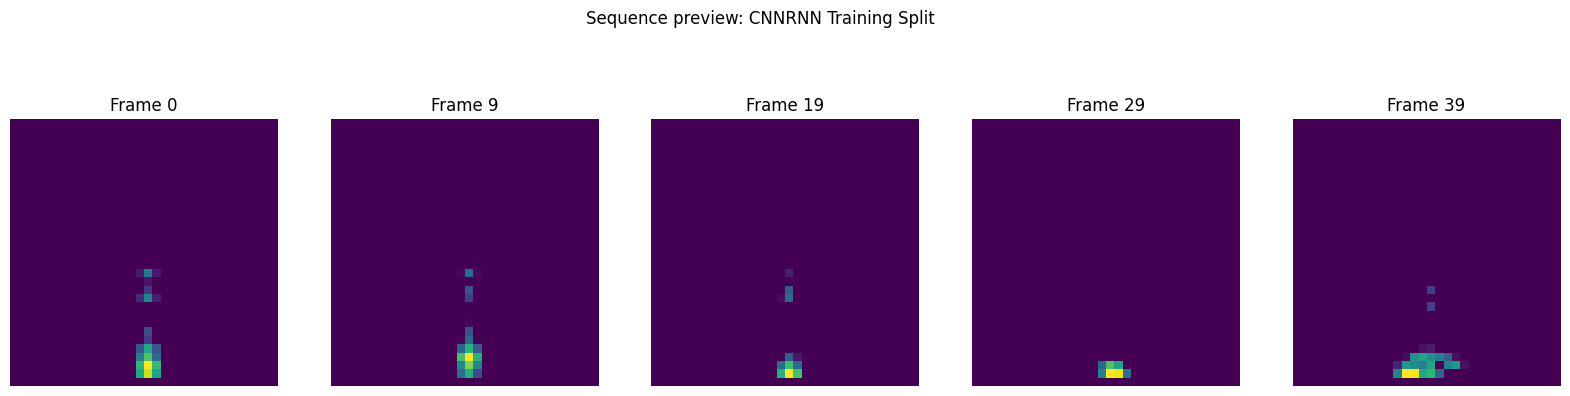

In [5]:
visualise_ds(cnn_rnn_test_ds)

# Testing best models' performance for each architecture

## CNN+RNN

163/163 ━━━━━━━━━━━━━━━━━━━━ 55s 269ms/step - accuracy: 0.9817 - loss: 0.0660
Accuracy from test set: 0.9793


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


163/163 ━━━━━━━━━━━━━━━━━━━━ 45s 222ms/step


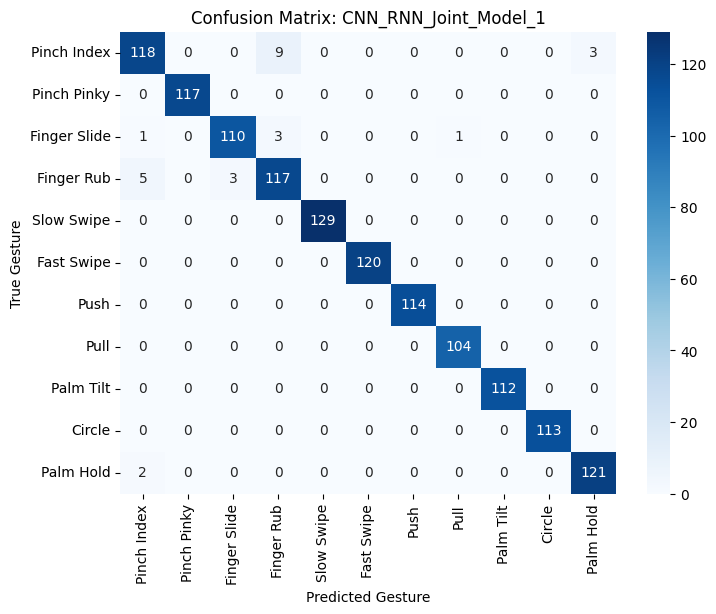

Accuracies per gesture
Pinch Index: 0.9077
Pinch Pinky: 1.0
Finger Slide: 0.9565
Finger Rub: 0.936
Slow Swipe: 1.0
Fast Swipe: 1.0
Push: 1.0
Pull: 1.0
Palm Tilt: 1.0
Circle: 1.0
Palm Hold: 0.9837
Global average accuracy: 0.9804
Parameter count: 3,517,163
Trainable: 3,513,643
Non-trainable: 3,520


In [6]:
#Best CNNRNN model, mimicking paper

model_path = "/kaggle/input/models/xxdiegoalonsoxx/model-1/tensorflow2/cnnrnn-1/2/CNN_RNN_Model_1.keras"
learning_rate = 3e-4
test_set = cnn_rnn_test_ds

model = load_model(model_path, learning_rate)
test_results = test_model(model, test_set)

print(f"Accuracy from test set: {test_results['accuracy']:.4f}")
cm, acc_x_gest = create_confusion_matrix(model, test_set)

163/163 ━━━━━━━━━━━━━━━━━━━━ 50s 236ms/step - accuracy: 0.9814 - loss: 0.0493
Accuracy from test set: 0.9816


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


163/163 ━━━━━━━━━━━━━━━━━━━━ 46s 227ms/step


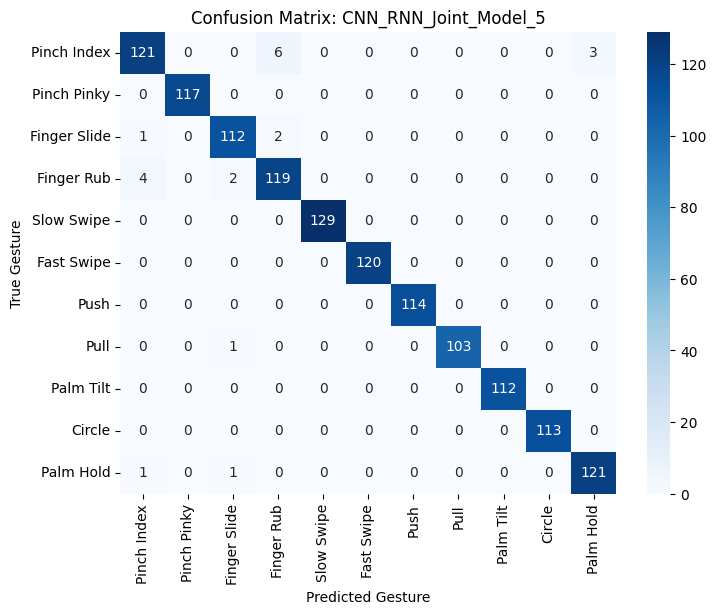

Accuracies per gesture
Pinch Index: 0.9308
Pinch Pinky: 1.0
Finger Slide: 0.9739
Finger Rub: 0.952
Slow Swipe: 1.0
Fast Swipe: 1.0
Push: 1.0
Pull: 0.9904
Palm Tilt: 1.0
Circle: 1.0
Palm Hold: 0.9837
Global average accuracy: 0.9846
Parameter count: 3,517,163
Trainable: 3,513,643
Non-trainable: 3,520


In [7]:
#CNN+RNN model 5 with avg pooling
model_path = "/kaggle/input/models/xxdiegoalonsoxx/model-1/tensorflow2/default/2/CNN_RNN_Model_5.keras"
learning_rate = 3e-4
test_set = cnn_rnn_test_ds

model = load_model(model_path, learning_rate)
test_results = test_model(model, test_set)

print(f"Accuracy from test set: {test_results['accuracy']:.4f}")
cm, acc_x_gest = create_confusion_matrix(model, test_set)

## AE+RNN

163/163 ━━━━━━━━━━━━━━━━━━━━ 41s 181ms/step - accuracy: 0.9801 - loss: 0.0786
Accuracy from test set: 0.9780


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


163/163 ━━━━━━━━━━━━━━━━━━━━ 40s 195ms/step


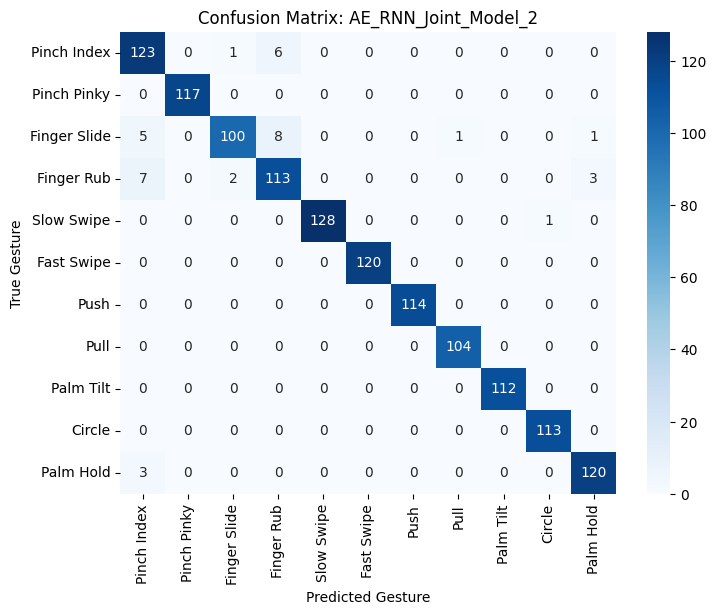

Accuracies per gesture
Pinch Index: 0.9462
Pinch Pinky: 1.0
Finger Slide: 0.8696
Finger Rub: 0.904
Slow Swipe: 0.9922
Fast Swipe: 1.0
Push: 1.0
Pull: 1.0
Palm Tilt: 1.0
Circle: 1.0
Palm Hold: 0.9756
Global average accuracy: 0.9716
Parameter count: 986,731
Trainable: 628,491
Non-trainable: 358,240


In [8]:
#Best AE+RNN 2 model, it provided same accuracy than AE+RNN 1 but with half of the neurons (256) on the RNN

model_path = "/kaggle/input/models/xxdiegoalonsoxx/model-1/tensorflow2/ae_rnn/4/AE_RNN_Model_2.keras"
learning_rate = 3e-4
test_set = cnn_rnn_test_ds

model = load_model(model_path, learning_rate)
test_results = test_model(model, test_set)

print(f"Accuracy from test set: {test_results['accuracy']:.4f}")
cm, acc_x_gest = create_confusion_matrix(model, test_set)

## LSM readout

In [9]:
#Best LSM readout + scikit classifier

model_path = "/kaggle/input/models/xxdiegoalonsoxx/model-1/tensorflow2/lsm-readout/1/LSM_Model_Readout.keras"
model = load_model(model_path, learning_rate)

X_train, Y_train = LSM_Readout(model, lsm_train_ds)
X_test, Y_test = LSM_Readout(model, lsm_test_ds)

svm = SVC(C = 128)
svm.fit(X_train, Y_train)

trainable_count = np.sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
non_trainable_count = np.sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights])

print(f"SVM GA Parameters Accuracy: {svm.score(X_test, Y_test):.4f}")

print(f"Parameter count: {trainable_count + non_trainable_count:,}")
print(f"Trainable: {trainable_count:,}")
print(f"Non-trainable: {non_trainable_count:,}")

SVM GA Parameters Accuracy: 0.9654
Parameter count: 1,114,112.0
Trainable: 0.0
Non-trainable: 1,114,112


## LSM+GA

163/163 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.9740 - loss: 0.1515
Accuracy from test set: 0.9702


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step


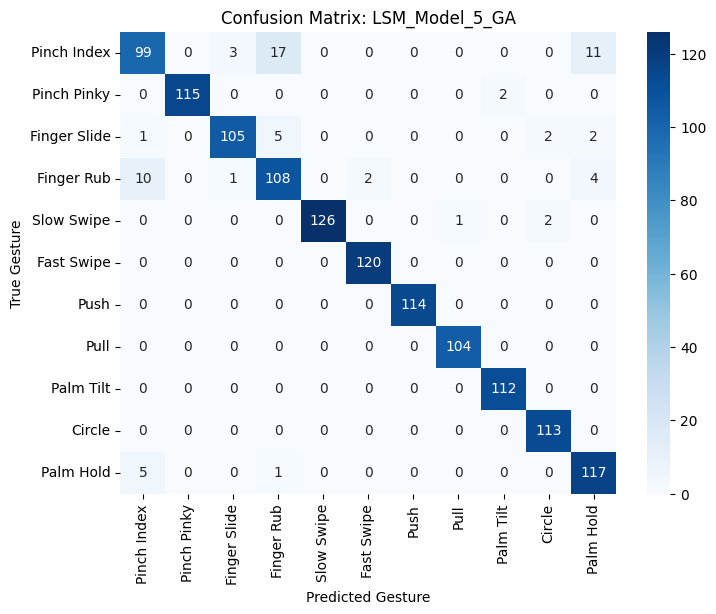

Accuracies per gesture
Pinch Index: 0.7615
Pinch Pinky: 0.9829
Finger Slide: 0.913
Finger Rub: 0.864
Slow Swipe: 0.9767
Fast Swipe: 1.0
Push: 1.0
Pull: 1.0
Palm Tilt: 1.0
Circle: 1.0
Palm Hold: 0.9512
Global average accuracy: 0.9499
Parameter count: 1,226,859
Trainable: 111,243
Non-trainable: 1,115,616


In [10]:
#Best LSM Model, LSM 5 with GA

model_path = "/kaggle/input/models/xxdiegoalonsoxx/model-1/tensorflow2/lsm2/3/LSM_Model_5_GA.keras"
learning_rate = 3e-4
test_set = lsm_test_ds

model = load_model(model_path, learning_rate)
test_results = test_model(model, test_set)

print(f"Accuracy from test set: {test_results['accuracy']:.4f}")
cm, acc_x_gest = create_confusion_matrix(model, test_set)

## AE+LSM

163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 165ms/step - accuracy: 0.9663 - loss: 0.1830
Accuracy from test set: 0.9625


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


163/163 ━━━━━━━━━━━━━━━━━━━━ 32s 160ms/step


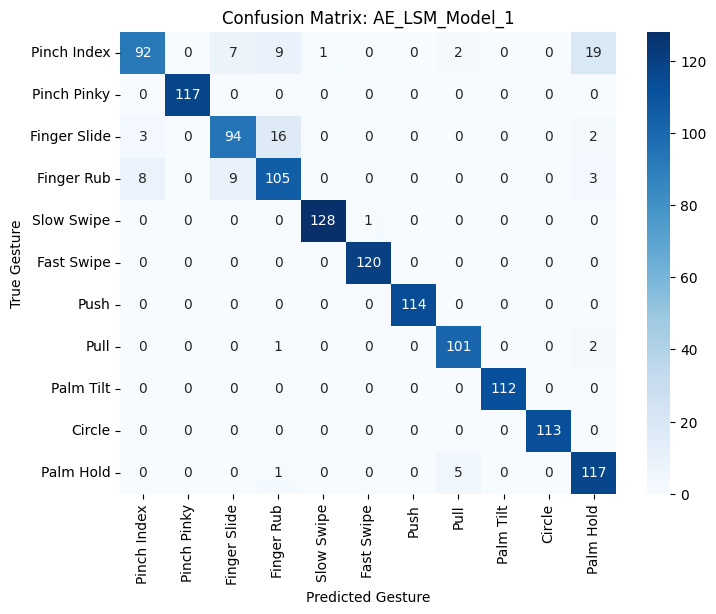

Accuracies per gesture
Pinch Index: 0.7077
Pinch Pinky: 1.0
Finger Slide: 0.8174
Finger Rub: 0.84
Slow Swipe: 0.9922
Fast Swipe: 1.0
Push: 1.0
Pull: 0.9712
Palm Tilt: 1.0
Circle: 1.0
Palm Hold: 0.9512
Global average accuracy: 0.9345
Parameter count: 458,859
Trainable: 3,339
Non-trainable: 455,520


In [11]:
model_path = "/kaggle/input/models/xxdiegoalonsoxx/model-1/tensorflow2/ae-lsm/3/AE_LSM_Model_1.keras"
learning_rate = 3e-4
test_set = cnn_rnn_test_ds

model = load_model(model_path, learning_rate)
test_results = test_model(model, test_set)

print(f"Accuracy from test set: {test_results['accuracy']:.4f}")
cm, acc_x_gest = create_confusion_matrix(model, test_set)

## CNN+LSM+GA

163/163 ━━━━━━━━━━━━━━━━━━━━ 38s 185ms/step - accuracy: 0.9576 - loss: 0.2501
Accuracy from test set: 0.9537


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


163/163 ━━━━━━━━━━━━━━━━━━━━ 32s 160ms/step


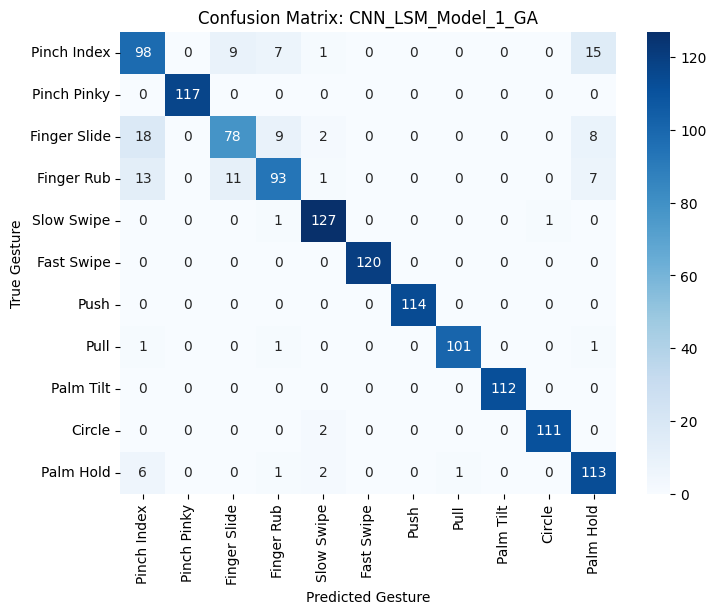

Accuracies per gesture
Pinch Index: 0.7538
Pinch Pinky: 1.0
Finger Slide: 0.6783
Finger Rub: 0.744
Slow Swipe: 0.9845
Fast Swipe: 1.0
Push: 1.0
Pull: 0.9712
Palm Tilt: 1.0
Circle: 0.9823
Palm Hold: 0.9187
Global average accuracy: 0.9121
Parameter count: 688,107
Trainable: 97,323
Non-trainable: 590,784


In [12]:
#Best CNN LSM model, Model 1 with GA

model_path = "/kaggle/input/models/xxdiegoalonsoxx/model-1/tensorflow2/cnn-lsm/3/CNN_LSM_Model_1_GA.keras"
learning_rate = 3e-4
test_set = cnn_rnn_test_ds

model = load_model(model_path, learning_rate)
test_results = test_model(model, test_set)

print(f"Accuracy from test set: {test_results['accuracy']:.4f}")
cm, acc_x_gest = create_confusion_matrix(model, test_set)

# Personalized classifiers (cross-session)

## AE+RNN 4

310/310 ━━━━━━━━━━━━━━━━━━━━ 66s 174ms/step - accuracy: 0.9354 - loss: 0.9371
Accuracy from test set: 0.9249


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


310/310 ━━━━━━━━━━━━━━━━━━━━ 59s 163ms/step


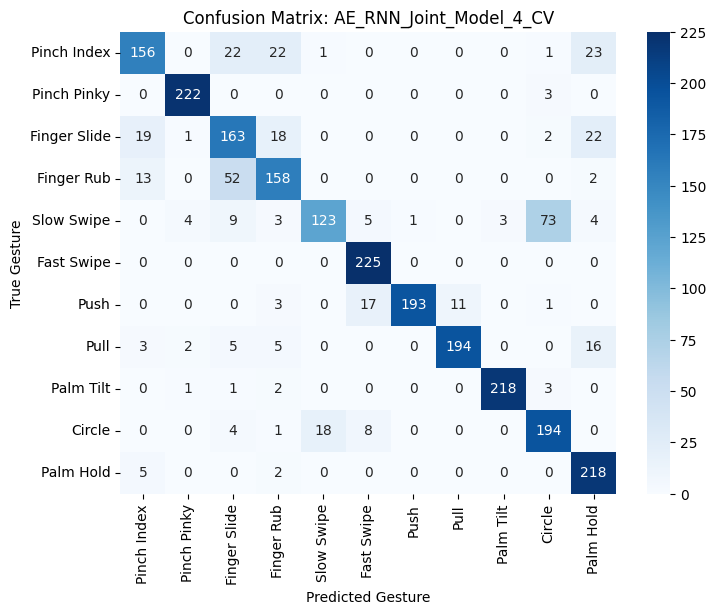

Accuracies per gesture
Pinch Index: 0.6933
Pinch Pinky: 0.9867
Finger Slide: 0.7244
Finger Rub: 0.7022
Slow Swipe: 0.5467
Fast Swipe: 1.0
Push: 0.8578
Pull: 0.8622
Palm Tilt: 0.9689
Circle: 0.8622
Palm Hold: 0.9689
Global average accuracy: 0.8339
Parameter count: 656,619
Trainable: 298,635
Non-trainable: 357,984


In [13]:
#Best AE+RNN model trained using cross-session

model_path = "/kaggle/input/models/xxdiegoalonsoxx/model-1/tensorflow2/cross_val/3/AE_RNN_Model_4_CV.keras"
learning_rate = 3e-4
test_set = cnn_rnn_test_ds_cv

model = load_model(model_path, learning_rate)
test_results = test_model(model, test_set)

print(f"Accuracy from test set: {test_results['accuracy']:.4f}")
cm, acc_x_gest = create_confusion_matrix(model, test_set)

## AE+LSM 2

163/163 ━━━━━━━━━━━━━━━━━━━━ 37s 174ms/step - accuracy: 0.9188 - loss: 0.9800
Accuracy from test set: 0.9146


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


163/163 ━━━━━━━━━━━━━━━━━━━━ 38s 193ms/step


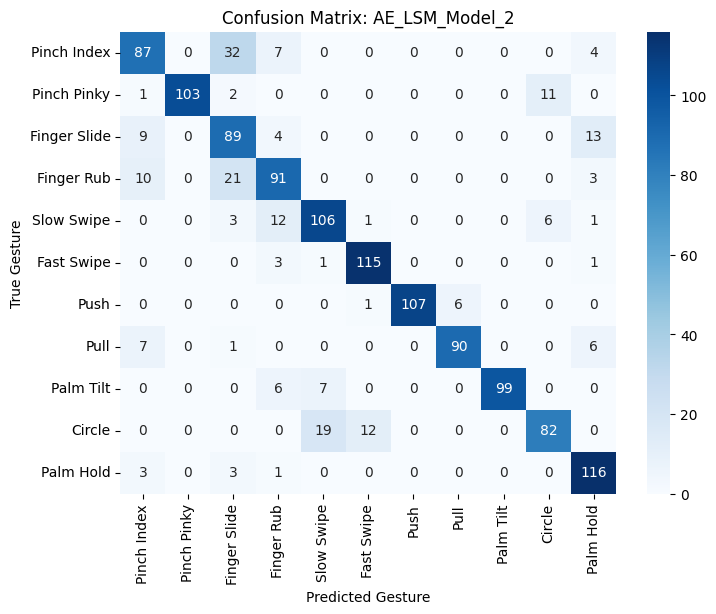

Accuracies per gesture
Pinch Index: 0.6692
Pinch Pinky: 0.8803
Finger Slide: 0.7739
Finger Rub: 0.728
Slow Swipe: 0.8217
Fast Swipe: 0.9583
Push: 0.9386
Pull: 0.8654
Palm Tilt: 0.8839
Circle: 0.7257
Palm Hold: 0.9431
Global average accuracy: 0.8353
Parameter count: 458,859
Trainable: 3,339
Non-trainable: 455,520


In [14]:
#Best CNN LSM model, Model 1 with GA

model_path = "/kaggle/input/models/xxdiegoalonsoxx/model-1/tensorflow2/cross_val/3/AE_LSM_Model_2_CV.keras"
learning_rate = 3e-4
test_set = cnn_rnn_test_ds

model = load_model(model_path, learning_rate)
test_results = test_model(model, test_set)

print(f"Accuracy from test set: {test_results['accuracy']:.4f}")
cm, acc_x_gest = create_confusion_matrix(model, test_set)